# Descriptive statistics: measurements, variation and uncertainty

```{admonition} Learning outcomes
After working through this topic, you should be able to:

1. explain why repeated chemical measurements vary
2. choose between the mean and median in simple chemical situations
3. explain what percentiles and the interquartile range tell us
4. use standard deviation and relative standard deviation to describe precision
5. distinguish between standard deviation, standard error and a confidence interval
6. calculate and interpret a 95% confidence interval for a mean
```

Repeated chemical measurements almost never give exactly the same result. Suppose we measure the iron concentration of the same solution five times:

In [16]:
measurements_mg_L = [5.12, 5.08, 5.15, 5.10, 5.13]

The differences are small, but real. They may arise from instrument noise, small differences in volume or temperature, and variation in sample preparation. Statistics helps us describe that variation and assess what the measurements collectively tell us.

We will repeatedly return to two questions:

1. **Where are the measurements centred?** We can describe this using the mean or median.
2. **How much do they vary?** We can describe this using the standard deviation or interquartile range.

The most useful quantities depend on how the data were generated.

## What have we measured?

Two common situations in chemistry are worth distinguishing:

- **Repeated measurements of the same sample.** Mean and standard deviation are often natural summaries when the variation is reasonably symmetric.
- **Measurements from many different samples.** Concentrations in environmental, clinical or geological samples may be strongly skewed. Median and interquartile range may then describe the distribution more clearly.

These are useful starting points rather than automatic rules. Always inspect the data and consider the sampling process.

## Where are the measurements?

### Mean

```{admonition} Mean
The arithmetic mean is the sum of the observations divided by the number of observations.
```

$$
\bar{x}=\frac{x_1+x_2+\cdots+x_n}{n}.
$$

In [17]:
import numpy as np

mean = np.mean(measurements_mg_L)
print(f"Mean: {mean:.3f} mg/L")

Mean: 5.116 mg/L


The mean is 5.116 mg/L. It uses information from every observation, which is useful for repeated measurements of one homogeneous sample. The same property also makes it sensitive to unusually high or low values. A single pipetting error can shift the mean noticeably.

### Median

```{admonition} Median
The median is the middle value after the observations have been sorted. If the number of observations is even, the median is the mean of the two middle values.
```

In [18]:
median = np.median(measurements_mg_L)
print(f"Median: {median:.3f} mg/L")

Median: 5.120 mg/L


The median is less affected by extreme values. It is therefore often useful for skewed distributions or datasets containing a few very high or low observations.

For example, nitrate concentrations measured in many streams may be low in most locations but much higher close to a few agricultural areas. The median may then describe a typical stream more meaningfully than the mean.

````{admonition} Check your understanding
:class: tip
Compare these datasets:

```{code-block} python
measurements_1 = np.array([10.02, 10.05, 9.98, 10.01, 10.04])
measurements_2 = np.array([10.02, 10.05, 9.98, 10.01, 10.42])

for measurements in [measurements_1, measurements_2]:
    print("Mean:", np.mean(measurements))
    print("Median:", np.median(measurements))
```
Which summary changes most when the final value changes?
````
```{admonition} Suggested answer
:class: tip, dropdown
The mean changes most because every value enters directly into its calculation. The median remains 10.02 in both datasets. This demonstrates robustness, but it does **not** show that 10.42 should automatically be deleted. The reason for the unusual observation must be investigated.
```


## Percentiles: positions in a distribution

```{admonition} Percentile
A percentile is a boundary in an ordered dataset. The 25th percentile, for example, is a value at or below which approximately 25% of the observations lie.
```

- The 25th percentile is also called the first quartile, $Q_1$.
- The 50th percentile is the median.
- The 75th percentile is the third quartile, $Q_3$.

A percentile is **not** a percentage of the largest value. It describes a position within the distribution. Consider nitrate concentrations from twelve streams:

In [19]:
nitrate_mg_L = np.array([
    0.42, 0.47, 0.50, 0.55, 0.58, 0.61,
    0.65, 0.72, 0.85, 1.10, 1.35, 2.80,
])

q1 = np.percentile(nitrate_mg_L, 25)
median = np.percentile(nitrate_mg_L, 50)
q3 = np.percentile(nitrate_mg_L, 75)

print(f"25th percentile: {q1:.2f} mg/L")
print(f"Median: {median:.2f} mg/L")
print(f"75th percentile: {q3:.2f} mg/L")

25th percentile: 0.54 mg/L
Median: 0.63 mg/L
75th percentile: 0.91 mg/L


With a small dataset, a percentile does not always coincide with one measured value. Software may interpolate between observations. Several interpolation conventions exist, so programs can give slightly different numbers for small samples even though the interpretation of the percentile is unchanged.

```{admonition} Chemical use of percentiles
Percentiles are useful when describing concentrations across many heterogeneous samples. A 95th percentile for a contaminant, for example, describes a high level exceeded by only about 5% of the observations.
```

## How much do the data vary?

### Range

```{admonition} Range
The range is the difference between the largest and smallest observation.
```

In [20]:
data_range = np.max(nitrate_mg_L) - np.min(nitrate_mg_L)
print(f"Range: {data_range:.2f} mg/L")

Range: 2.38 mg/L


The range is simple, but it depends on only two observations. One extreme value can therefore dominate it. It is useful for a quick overview but rarely as the only description of spread.

### Interquartile range

The interval from $Q_1$ to $Q_3$ contains the middle 50% of the observations.

```{admonition} Interquartile range (IQR)
The interquartile range is

$$IQR=Q_3-Q_1.$$

It describes the spread of the middle 50% of the data and is less sensitive to extreme observations than the range or standard deviation.
```

In [21]:
iqr = q3 - q1
print(f"IQR: {iqr:.2f} mg/L")

IQR: 0.37 mg/L


For strongly skewed environmental concentrations, reporting **median + IQR** is often informative because both quantities are relatively robust to a few unusually high values.

A box plot visualises the median, quartiles and potential outliers according to a plotting rule:

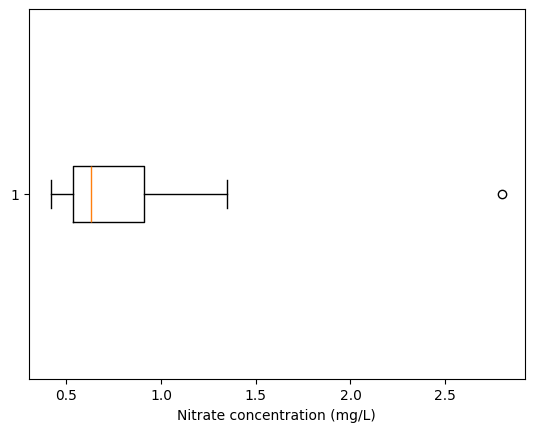

In [22]:
import matplotlib.pyplot as plt

plt.boxplot(nitrate_mg_L, vert=False)
plt.xlabel("Nitrate concentration (mg/L)")
plt.show()

In the conventional Tukey box plot, the whiskers extend to observations within $1.5\,IQR$ of the quartiles; observations beyond them are drawn separately. These are **potential outliers**, not automatically erroneous measurements. A chemical or experimental reason is needed before excluding a value.

### Standard deviation

```{admonition} Sample standard deviation
The sample standard deviation describes the typical spread of observations around their mean:

$$
s=\sqrt{\frac{\sum_{i=1}^{n}(x_i-\bar{x})^2}{n-1}}.
$$
```

For experimental replicates we normally use the **sample** standard deviation, with $n-1$ in the denominator. In NumPy that corresponds to `ddof=1`.

In [23]:
measurements = np.array(measurements_mg_L)
standard_deviation = np.std(measurements, ddof=1)
print(f"Standard deviation: {standard_deviation:.3f} mg/L")

Standard deviation: 0.027 mg/L


The standard deviation has the **same unit as the measurement**. A smaller standard deviation means the replicate values lie closer to their mean and therefore indicates better repeatability under the conditions used.

Standard deviation is sensitive to large deviations because the differences from the mean are squared. That is useful when the data genuinely follow an approximately symmetric measurement distribution, but less robust for strongly skewed heterogeneous datasets.

### Relative standard deviation

When the magnitude of measurements differs substantially, it can be useful to express the spread relative to the mean.

```{admonition} Relative standard deviation (RSD)
$$
RSD=\frac{s}{\bar{x}}\times100\%.
$$

RSD is often used to express analytical precision as a percentage.
```

In [24]:
mean = np.mean(measurements)
rsd = standard_deviation / mean * 100
print(f"RSD: {rsd:.2f}%")

RSD: 0.53%


RSD is poorly behaved when the mean is close to zero: a small absolute variation can then produce a very large percentage.

## What should we use when?

| Situation | Useful summaries | Example |
|---|---|---|
| Repeated measurements of one homogeneous sample, roughly symmetric | mean + SD | repeated titrations or instrumental replicates |
| Many heterogeneous samples, skewed distribution | median + IQR | contaminant concentrations across many sites |
| Comparing precision at different signal levels | RSD, with care | replicate measurements at several concentrations |
| Quick overview of extremes | range | screening a small batch of measurements |

These are not automatic rules. Always inspect the raw data and how the samples were collected.

## From spread to uncertainty in the mean

So far we have described the observations we actually measured. Often we also want to use those observations to estimate an unknown mean.

This distinction is fundamental:

- **Standard deviation (SD)** describes the spread of individual measurements.
- **Standard error (SE)** describes how precisely the sample mean estimates the underlying mean.

```{admonition} Standard error of the mean
For $n$ independent measurements with sample standard deviation $s$,

$$
SE=\frac{s}{\sqrt{n}}.
$$
```

In [25]:
n = len(measurements)
standard_error = standard_deviation / np.sqrt(n)
print(f"Standard error: {standard_error:.3f} mg/L")

Standard error: 0.012 mg/L


Why does $\sqrt{n}$ appear? Imagine repeating the entire experiment many times. Each experiment produces a slightly different sample mean. Means calculated from more independent observations fluctuate less than means calculated from only a few observations. Under the usual assumptions, the standard deviation of those hypothetical sample means is $s/\sqrt{n}$.

The SE therefore becomes smaller as we collect more independent measurements. The SD need not become smaller: individual measurements can remain just as variable even though their mean is estimated more precisely.

## Confidence interval for the mean

The mean 5.116 mg/L is our best single estimate from these five measurements. But if we prepared five new samples and repeated the measurements, the new mean would probably be a little different. A confidence interval expresses the uncertainty of the **estimated mean**, not the spread of individual measurements.

```{admonition} 95% confidence interval
A 95% confidence interval is produced by a procedure designed so that, under its assumptions, approximately 95% of intervals calculated from many repeated experiments would contain the true population mean.
```

This wording matters. For one interval already calculated from our data, the true mean is fixed; it is not correct in the frequentist interpretation to say that there is a 95% probability that this particular interval contains it. The 95% describes the long-run performance of the **method** used to construct the interval.

### Why 95%?

90%, 95% and 99% are common choices. A higher confidence level gives a procedure with greater long-run coverage, but the interval becomes wider. There is therefore a trade-off between confidence level and precision.

95% is a convention, not a law of nature. It is commonly used because it provides a useful compromise in many scientific contexts.

### From the standard error to an interval

If the population standard deviation were known and the sampling distribution were normal, we could use a normal-distribution multiplier. In small chemical datasets, however, we usually estimate the standard deviation from the same measurements. That introduces extra uncertainty.

We therefore use **Student's t-distribution**, which has heavier tails than the normal distribution. The required multiplier is called a **t critical value**.

For a two-sided 95% interval:

$$
\bar{x}\pm t_{0.975,\,n-1}\frac{s}{\sqrt{n}}.
$$

The degrees of freedom are

$$
df=n-1.
$$

With few measurements, the t critical value is larger. As $n$ grows, the t-distribution approaches the normal distribution.

In [26]:
import numpy as np
from scipy import stats

measurements = np.array([5.12, 5.08, 5.15, 5.10, 5.13])

n = len(measurements)
mean = np.mean(measurements)
standard_deviation = np.std(measurements, ddof=1)
standard_error = standard_deviation / np.sqrt(n)

degrees_of_freedom = n - 1
t_critical = stats.t.ppf(0.975, degrees_of_freedom)
margin_of_error = t_critical * standard_error

lower = mean - margin_of_error
upper = mean + margin_of_error

print(f"Mean: {mean:.3f} mg/L")
print(f"95% CI: {lower:.3f} to {upper:.3f} mg/L")

Mean: 5.116 mg/L
95% CI: 5.082 to 5.150 mg/L


The calculation can be remembered as a chain:

$$
\text{measurements}\rightarrow s\rightarrow SE\rightarrow t\cdot SE\rightarrow\text{confidence interval}.
$$

The interactive example below lets you change the measurements and see how the interval responds.

<iframe src="../../basthon/?from=examples/statistics_confidence_interval.py" width="100%" height="700" frameborder="0" title="Interactive Python editor for a confidence interval" loading="lazy" allowfullscreen></iframe>

### Interpreting the interval

Imagine repeating the **whole experiment** very many times. Each time we make five new independent measurements and calculate a new 95% confidence interval by exactly the same procedure. The intervals would differ because the measurements differ. In the long run, about 95% of those intervals would contain the true mean if the assumptions are satisfied.

For our one experiment we can report the interval as a range of values compatible with the data and model at the chosen confidence level. It gives much more information than reporting only the point estimate.

## Reporting and rounding

Python calculates many more digits than are scientifically meaningful. Distinguish **calculation precision** from **reporting precision**.

A useful practice is to round the uncertainty to one or two significant figures and round the mean to the same decimal place. For example, depending on the convention used, the result could be reported in a compact form such as

$$5.116\;\text{mg/L}\quad(95\%\;CI:\;5.082\text{–}5.150\;\text{mg/L}).$$

Avoid rounding intermediate values aggressively; round when reporting the final result.

### What makes a confidence interval narrower or wider?

- **Larger SD → wider interval.** More variable measurements make the mean less precisely determined.
- **More independent measurements → narrower interval**, because $SE=s/\sqrt{n}$.
- **Higher confidence level → wider interval**, because a larger critical value is needed.
- **Fewer measurements → larger t multiplier**, because the estimated SD is less certain.

Collecting more measurements helps only if they provide genuinely new information. Re-reading the same sample under conditions that share the same systematic error does not make that systematic error disappear.

### When can we use this interval?

The simple t-based interval assumes that the observations are independent and that the underlying measurement distribution is reasonably compatible with normality. With very small $n$, strong skewness or outliers are difficult to assess, so experimental knowledge is particularly important.

The interval also addresses **random variation of the mean under the model**. It does not automatically include systematic errors such as an incorrectly calibrated pipette, a biased analytical method or a wrong standard concentration. A narrow confidence interval can therefore coexist with an inaccurate result.

### Error bars with standard deviation

If the purpose of error bars is to show the **spread among replicate measurements**, use standard deviation rather than standard error. Suppose we have three replicates for five concentrations:

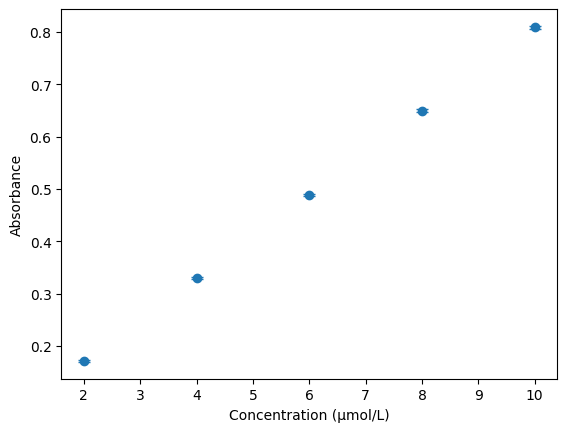

In [27]:
import numpy as np
import matplotlib.pyplot as plt

concentration_uM = np.array([2, 4, 6, 8, 10])
absorbance_replicates = np.array([
    [0.171, 0.169, 0.172],
    [0.329, 0.331, 0.328],
    [0.489, 0.491, 0.487],
    [0.648, 0.652, 0.650],
    [0.807, 0.812, 0.809],
])

mean_absorbance = np.mean(absorbance_replicates, axis=1)
sd_absorbance = np.std(absorbance_replicates, axis=1, ddof=1)

plt.errorbar(concentration_uM, mean_absorbance, yerr=sd_absorbance, fmt="o", capsize=4)
plt.xlabel("Concentration (µmol/L)")
plt.ylabel("Absorbance")
plt.show()

Here `axis=1` tells NumPy to calculate across the columns of each row: the three replicate values belong to one concentration. The error bars show **SD**, so they describe replicate spread. If the scientific question instead concerned uncertainty in the estimated mean, SE or a confidence interval might be more appropriate. Always state what the error bars represent.

## Statistics with Pandas

NumPy is convenient for one or a few measurement series. For a larger structured dataset with many rows and named variables, a Pandas DataFrame is often easier to work with. Pandas provides `.mean()`, `.median()`, `.std()`, `.quantile()` and `.describe()`.

The following synthetic dataset represents 200 samples with measurements of three metals.

In [28]:
import pandas as pd
import numpy as np

rng = np.random.default_rng(42)

data = pd.DataFrame({
    "iron_mg_L": rng.normal(5.0, 0.08, 200),
    "copper_mg_L": rng.normal(0.80, 0.05, 200),
    "zinc_mg_L": rng.normal(1.50, 0.10, 200),
})

print(data.head())
print(data.describe())

   iron_mg_L  copper_mg_L  zinc_mg_L
0   5.024377     0.816879   1.482039
1   4.916801     0.870374   1.519678
2   5.060036     0.804529   1.582053
3   5.075245     0.832197   1.460626
4   4.843917     0.697491   1.552117
        iron_mg_L  copper_mg_L   zinc_mg_L
count  200.000000   200.000000  200.000000
mean     4.997564     0.801004    1.493188
std      0.070555     0.050975    0.101651
min      4.829436     0.671667    1.203547
25%      4.947474     0.765184    1.421875
50%      4.995852     0.803022    1.492161
75%      5.042802     0.831957    1.556259
max      5.233109     0.945253    1.759767


In [29]:
print("Means:")
print(data.mean())

print("\nSample standard deviations:")
print(data.std())

print("\nMedians:")
print(data.median())

print("\nInterquartile ranges:")
print(data.quantile(0.75) - data.quantile(0.25))

Means:
iron_mg_L      4.997564
copper_mg_L    0.801004
zinc_mg_L      1.493188
dtype: float64

Sample standard deviations:
iron_mg_L      0.070555
copper_mg_L    0.050975
zinc_mg_L      0.101651
dtype: float64

Medians:
iron_mg_L      4.995852
copper_mg_L    0.803022
zinc_mg_L      1.492161
dtype: float64

Interquartile ranges:
iron_mg_L      0.095327
copper_mg_L    0.066772
zinc_mg_L      0.134385
dtype: float64


Pandas calculates these statistics **column by column**. Each column here represents one measured variable, so we obtain one mean, standard deviation and median for each metal.

This differs from the two-dimensional NumPy replicate example, where we explicitly used `axis=1` because replicates were arranged across each row. In a tidy DataFrame, **each row is normally one observation and each column one variable**, and Pandas methods operate down columns by default.

Pandas does not replace the statistical concepts. It is simply a convenient way to apply them to larger, labelled datasets.

## Short summary

- Mean and SD are often useful for repeated measurements of the same sample.
- Median and IQR are more robust and are often useful for skewed distributions across heterogeneous samples.
- SD describes the spread of individual observations.
- SE describes the precision of a sample mean and decreases approximately as $1/\sqrt{n}$.
- A t-based confidence interval combines the estimated mean, SE and a critical t value.
- A 95% confidence interval refers to the long-run coverage of the interval procedure, not a 95% probability assigned to one fixed interval after it has been calculated.
- Statistical summaries must always be interpreted together with the raw data and experimental design.

## Exercises

```{admonition} Exercise 3.1 — percentiles
:class: tip
Use the nitrate dataset from the chapter. Calculate the 10th, 25th, 50th, 75th and 90th percentiles. Explain in words what the 90th percentile means.
```

```{admonition} Exercise 3.2 — mean or median?
:class: tip
Create a copy of the nitrate dataset in which the largest value is changed from 2.80 to 8.00 mg/L. Compare mean, median, SD and IQR before and after the change. Which quantities are most robust?
```

```{admonition} Exercise 3.3 — SD and RSD
:class: tip
Two methods give replicate results of approximately 0.50 mg/L and 50 mg/L, respectively. Construct example datasets with the same RSD but different absolute SDs. Explain why both absolute and relative precision can matter.
```

```{admonition} Exercise 3.4 — standard error
:class: tip
For the iron measurements, calculate the SE for $n=5$. Then imagine the same SD with $n=20$. By what factor does the SE change? Why does increasing $n$ not necessarily improve accuracy?
```

```{admonition} Exercise 3.5 — confidence interval
:class: tip
Calculate 90%, 95% and 99% confidence intervals for the iron mean. Compare their widths and explain the trade-off.
```

```{admonition} Exercise 3.6 — interpretation
:class: tip
Evaluate the statement: "There is a 95% probability that the true concentration lies inside the 95% confidence interval we just calculated." Rewrite it using a correct frequentist interpretation.
```

```{admonition} Exercise 3.7 — error bars
:class: tip
Use the replicate UV–Vis data to plot mean absorbance with SD error bars. Then calculate SE error bars. Explain why the two figures answer different questions.
```

```{admonition} Exercise 3.8 — Pandas
:class: tip
Extend the 200-row DataFrame with a fourth synthetic analyte. Use `describe`, `mean`, `median`, `std` and `quantile` to summarise it. Introduce a few unusually high values and compare which summaries change most.
```